# 03. 혼잡도 EDA: 인기 장소의 경험 저하를 어떻게 줄일 것인가

## 비즈니스 질문

인기 장소를 추천해도 방문 시간이 혼잡하면 사용자는 좋은 경험을 하지 못한다.
따라서 읍면동+시간대별 혼잡도를 분석해, UI 일정에 혼잡도 등급을 붙이고 혼잡 시간대를 피하도록 설계했다.

## 왜 이 계산법을 썼나

- `z_score`: 지역별 이용량이 평균 대비 얼마나 튀는지 확인한다.
- `min_max`: 0~1 사이로 상대 혼잡도를 비교하기 쉽게 만든다.
- `quantile_level`: 고정 기준만으로 놓치는 지역별 분포 차이를 보완한다.
- `final_level`: 사용자에게 설명 가능한 최종 등급으로 변환한다.



In [1]:
from pathlib import Path
import sys, os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# matplotlib 캐시는 이 EDA 폴더 안에만 만들도록 고정한다.
MPL_CACHE_DIR = Path(r'C:/Users/hyunj/Seoul_Strolling_Adventure/Business_Impact_EDA/.matplotlib_cache')
MPL_CACHE_DIR.mkdir(exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPL_CACHE_DIR))

import matplotlib
if 'ipykernel' not in sys.modules:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'Business_Impact_EDA' else Path(r'C:/Users/hyunj/Seoul_Strolling_Adventure')

# 노트북/Colab/로컬 환경에서 한글 폰트가 깨지지 않도록 설정
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
    get_ipython().run_line_magic('config', "InlineBackend.figure_format = 'retina'")
except Exception:
    pass

import os
import shutil
import subprocess
import matplotlib as mpl
from matplotlib import font_manager as fm

# Colab/Linux 계열이면 나눔/Noto CJK 폰트 설치를 시도한다.
# Windows 로컬에서는 apt-get이 없으므로 설치를 건너뛰고 Malgun Gothic을 우선 사용한다.
if shutil.which('apt-get'):
    try:
        subprocess.run(['apt-get', 'update', '-qq'], check=False)
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum', 'fonts-nanum-extra', 'fonts-noto-cjk'],
                       check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    except Exception as e:
        print('폰트 설치 단계 건너뜀:', e)

# 캐시 삭제 & 폰트 매니저 재로딩
try:
    shutil.rmtree(mpl.get_cachedir(), ignore_errors=True)
    Path(mpl.get_cachedir()).mkdir(parents=True, exist_ok=True)
    fm._load_fontmanager(try_read_cache=False)
except Exception as e:
    print('폰트 캐시 초기화 단계 건너뜀:', e)

# 우선순위: Colab/Linux용 나눔바른고딕 > 나눔고딕 > Noto CJK > Windows 맑은 고딕
candidates = ['NanumBarunGothic', 'NanumGothic', 'Noto Sans CJK KR', 'Malgun Gothic', 'AppleGothic']
avail = {name: any(name in font.name for font in fm.fontManager.ttflist) for name in candidates}
chosen = next((name for name in candidates if avail.get(name)), 'DejaVu Sans')

sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = [chosen]
plt.rcParams['axes.unicode_minus'] = False
print('Using font:', chosen)

def read_csv(path, **kwargs):
    for enc in ['utf-8-sig', 'utf-8', 'cp949']:
        try:
            return pd.read_csv(path, encoding=enc, **kwargs)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path, **kwargs)

def find_csv_by_cols(folder, required_cols):
    for p in sorted(Path(folder).rglob('*.csv')):
        try:
            cols = set(read_csv(p, nrows=0).columns)
            if set(required_cols).issubset(cols):
                return p
        except Exception:
            pass
    raise FileNotFoundError(f'{folder} 안에서 컬럼 {required_cols}를 가진 csv를 찾지 못했습니다.')

def pct(a, b):
    if b == 0 or pd.isna(b):
        return np.nan
    return (a - b) / b * 100

DATA = {
    'ui_places': find_csv_by_cols(PROJECT_ROOT / 'UI', ['title', 'tour_score', 'review_score']),
    'congestion': find_csv_by_cols(PROJECT_ROOT / 'UI' / 'congestion_level', ['시간대', 'final_level']),
    'tourism_index': next(PROJECT_ROOT.rglob('final_data_Tourism.csv')),
    'popularity': PROJECT_ROOT / 'EDA' / 'popularity' / 'popularity_result.csv',
    'reviews': PROJECT_ROOT / 'EDA' / 'popularity' / 'zb_review_data_final.csv',
}

print('PROJECT_ROOT =', PROJECT_ROOT)
print('사용 데이터 존재 여부')
for k, v in DATA.items():
    print(f'{k:15s}: {v.exists()} | {v.relative_to(PROJECT_ROOT)}')






Using font: NanumGothic
PROJECT_ROOT = c:\Users\hyunj\Seoul_Strolling_Adventure
사용 데이터 존재 여부
ui_places      : True | UI\관광지_법정동_매핑결과.csv
congestion     : True | UI\congestion_level\혼잡도 최종등급_전국.csv
tourism_index  : True | EDA\관광지수\final_data_Tourism.csv
popularity     : True | EDA\popularity\popularity_result.csv
reviews        : True | EDA\popularity\zb_review_data_final.csv


In [2]:
cong = read_csv(DATA['congestion'])
level_order = ['여유', '보통', '붐빔', '매우 붐빔']
cong['final_level'] = pd.Categorical(cong['final_level'], categories=level_order, ordered=True)
cong['hour'] = cong['시간대'].astype(str).str.extract(r'(\d+)').astype(float)
cong['risk_score'] = cong['final_level'].cat.codes + 1
cong.head()


,시도,시군구,읍면동,시간대,혼잡도,z_score,min_max,fixed_level,quantile_level,final_level,hour,risk_score
0,강원특별자치도,강릉시,강동면,00시,0.0,-0.208343,0.305210,여유,여유,여유,0.0,1
1,강원특별자치도,강릉시,강동면,01시,0.0,-0.148646,0.487438,보통,보통,보통,1.0,2
2,강원특별자치도,강릉시,강동면,02시,0.0,-0.045185,0.662540,보통,붐빔,붐빔,2.0,3
3,강원특별자치도,강릉시,강동면,03시,0.0,0.015151,0.658748,보통,붐빔,붐빔,3.0,3
4,강원특별자치도,강릉시,강동면,04시,0.0,0.164789,0.739262,보통,붐빔,붐빔,4.0,3


In [3]:
hourly = cong.groupby('시간대', observed=False).agg(
    avg_congestion=('혼잡도','mean'),
    avg_risk=('risk_score','mean'),
    very_busy_rate=('final_level', lambda s: (s.astype(str).eq('매우 붐빔')).mean()*100),
    busy_or_more_rate=('final_level', lambda s: (s.astype(str).isin(['붐빔','매우 붐빔'])).mean()*100)
).reset_index()
hourly['hour'] = hourly['시간대'].str.extract(r'(\d+)').astype(int)
hourly = hourly.sort_values('hour')
peak = hourly.loc[hourly['busy_or_more_rate'].idxmax()]
quiet = hourly.loc[hourly['busy_or_more_rate'].idxmin()]
print(f"가장 혼잡한 시간대: {peak['시간대']} | 붐빔 이상 비율 {peak['busy_or_more_rate']:.1f}%")
print(f"가장 여유로운 시간대: {quiet['시간대']} | 붐빔 이상 비율 {quiet['busy_or_more_rate']:.1f}%")
hourly.head()


가장 혼잡한 시간대: 17시 | 붐빔 이상 비율 99.5%
가장 여유로운 시간대: 09시 | 붐빔 이상 비율 0.1%


,시간대,avg_congestion,avg_risk,very_busy_rate,busy_or_more_rate,hour
0,00시,398.979806,1.169958,0.063025,6.008403,0
1,01시,41.213043,2.055882,0.147059,5.651261,1
2,02시,5.099081,2.983403,0.882353,97.563025,2
3,03시,-1.295861,2.843277,0.567227,90.420168,3
4,04시,-153.508053,2.932353,1.638655,91.785714,4


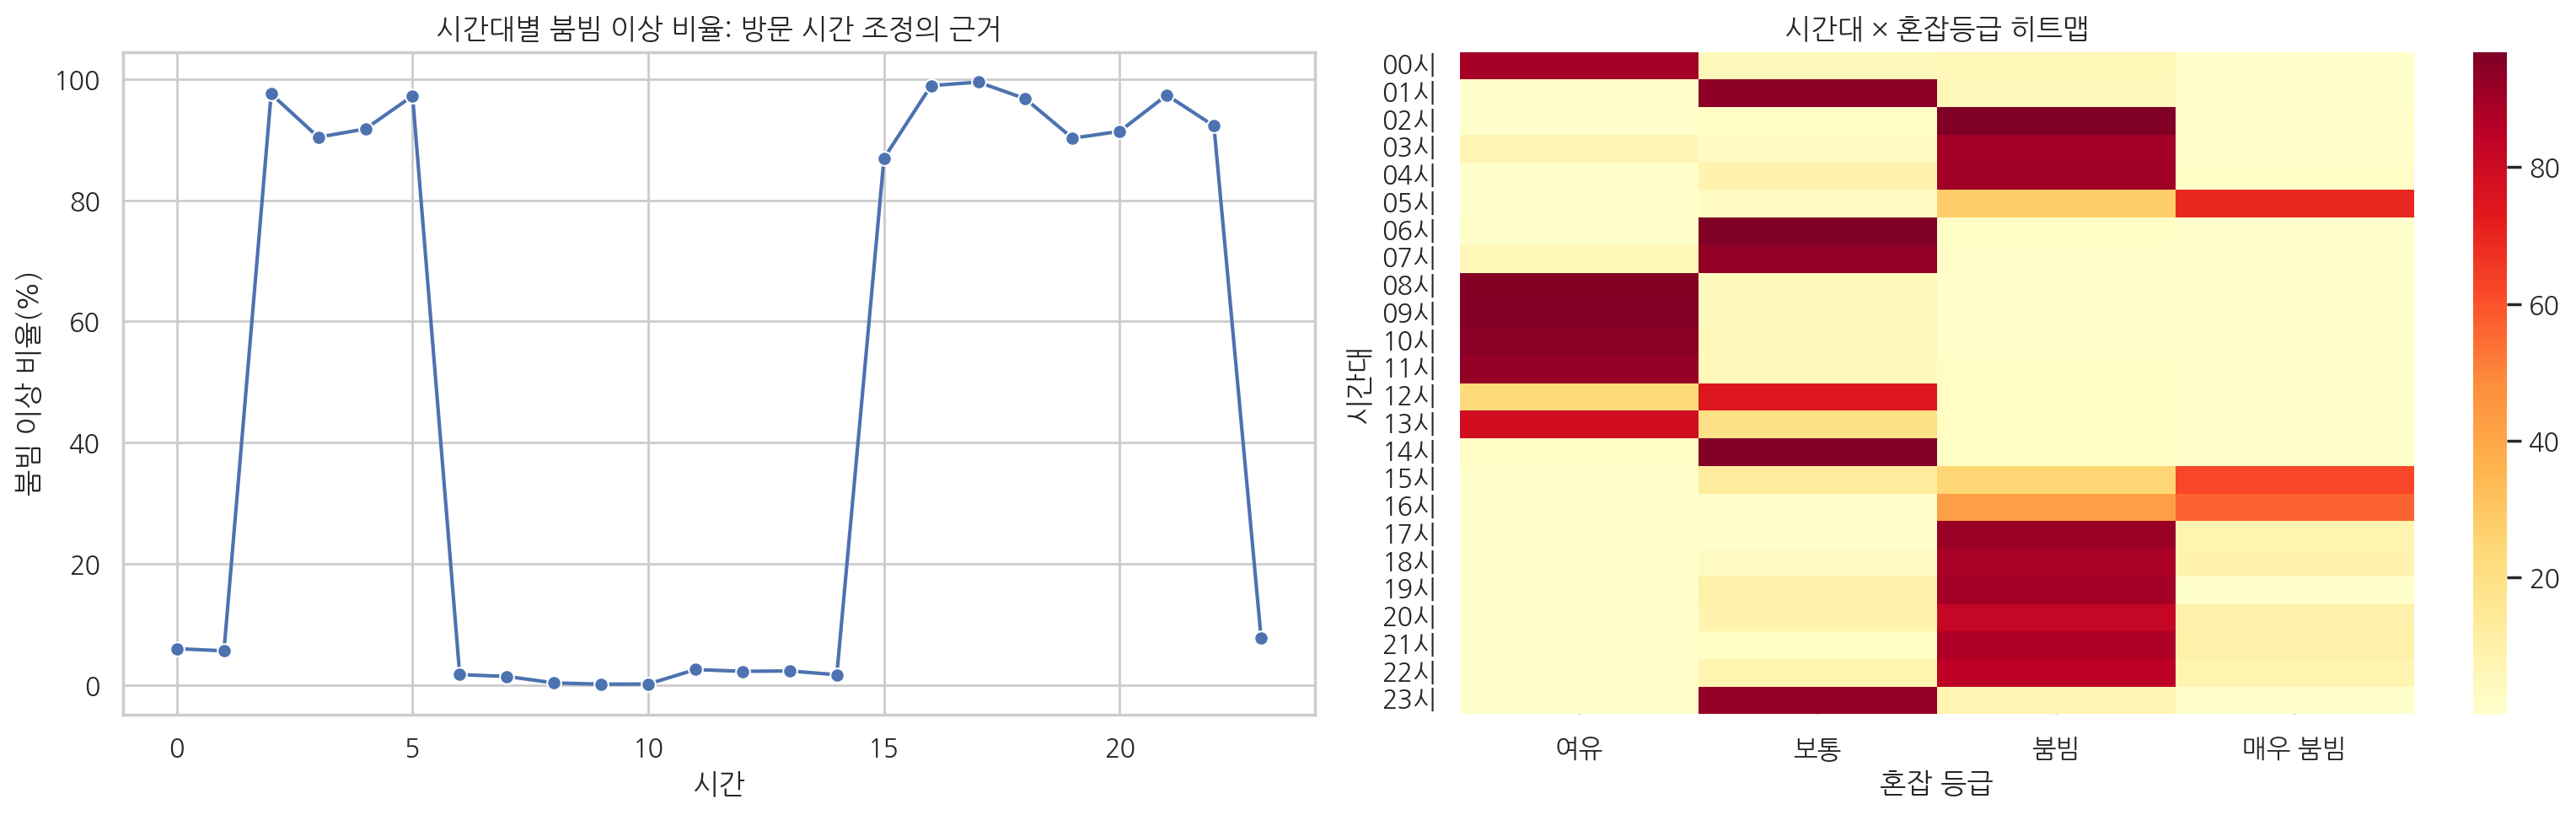

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=hourly, x='hour', y='busy_or_more_rate', marker='o', ax=axes[0])
axes[0].set_title('시간대별 붐빔 이상 비율: 방문 시간 조정의 근거')
axes[0].set_xlabel('시간')
axes[0].set_ylabel('붐빔 이상 비율(%)')
level_dist = pd.crosstab(cong['시간대'], cong['final_level'], normalize='index') * 100
level_dist = level_dist.reindex([f'{h:02d}시' for h in range(24) if f'{h:02d}시' in level_dist.index])
sns.heatmap(level_dist[level_order], cmap='YlOrRd', annot=False, ax=axes[1])
axes[1].set_title('시간대 × 혼잡등급 히트맵')
axes[1].set_xlabel('혼잡 등급')
axes[1].set_ylabel('시간대')
plt.tight_layout()
plt.show()


## 검정: 출퇴근/낮 시간대의 혼잡도 차이가 유의한가?

서비스에서는 단순히 “낮이 붐빈다”라고 말하는 것이 아니라, 실제 데이터로 시간대 차이를 확인해야 한다. 유의하지 않다면 시간대 하나로 단정하지 않고, 지역별 혼잡 리스크까지 함께 보는 방식으로 보완한다.



In [5]:
commute_hours = ['07시','08시','09시','17시','18시','19시']
leisure_hours = ['11시','12시','13시','14시','15시','16시']
commute = cong[cong['시간대'].isin(commute_hours)]['risk_score'].dropna()
leisure = cong[cong['시간대'].isin(leisure_hours)]['risk_score'].dropna()
t_stat, p_value = stats.ttest_ind(commute, leisure, equal_var=False)
print(f'출퇴근 시간 평균 위험점수: {commute.mean():.2f}')
print(f'낮 관광 시간 평균 위험점수: {leisure.mean():.2f}')
print(f'차이율: {pct(commute.mean(), leisure.mean()):.1f}%')
print(f'Welch t-test p-value: {p_value:.4g}')
print('해석: 출퇴근/낮 구분만으로는 차이가 강하게 유의하지 않아, 시간대 단독 기준보다 지역별 혼잡 리스크와 함께 보완하는 전략이 필요하다.')



출퇴근 시간 평균 위험점수: 2.18
낮 관광 시간 평균 위험점수: 2.20
차이율: -0.7%
Welch t-test p-value: 0.07166
해석: 출퇴근/낮 구분만으로는 차이가 강하게 유의하지 않아, 시간대 단독 기준보다 지역별 혼잡 리스크와 함께 보완하는 전략이 필요하다.


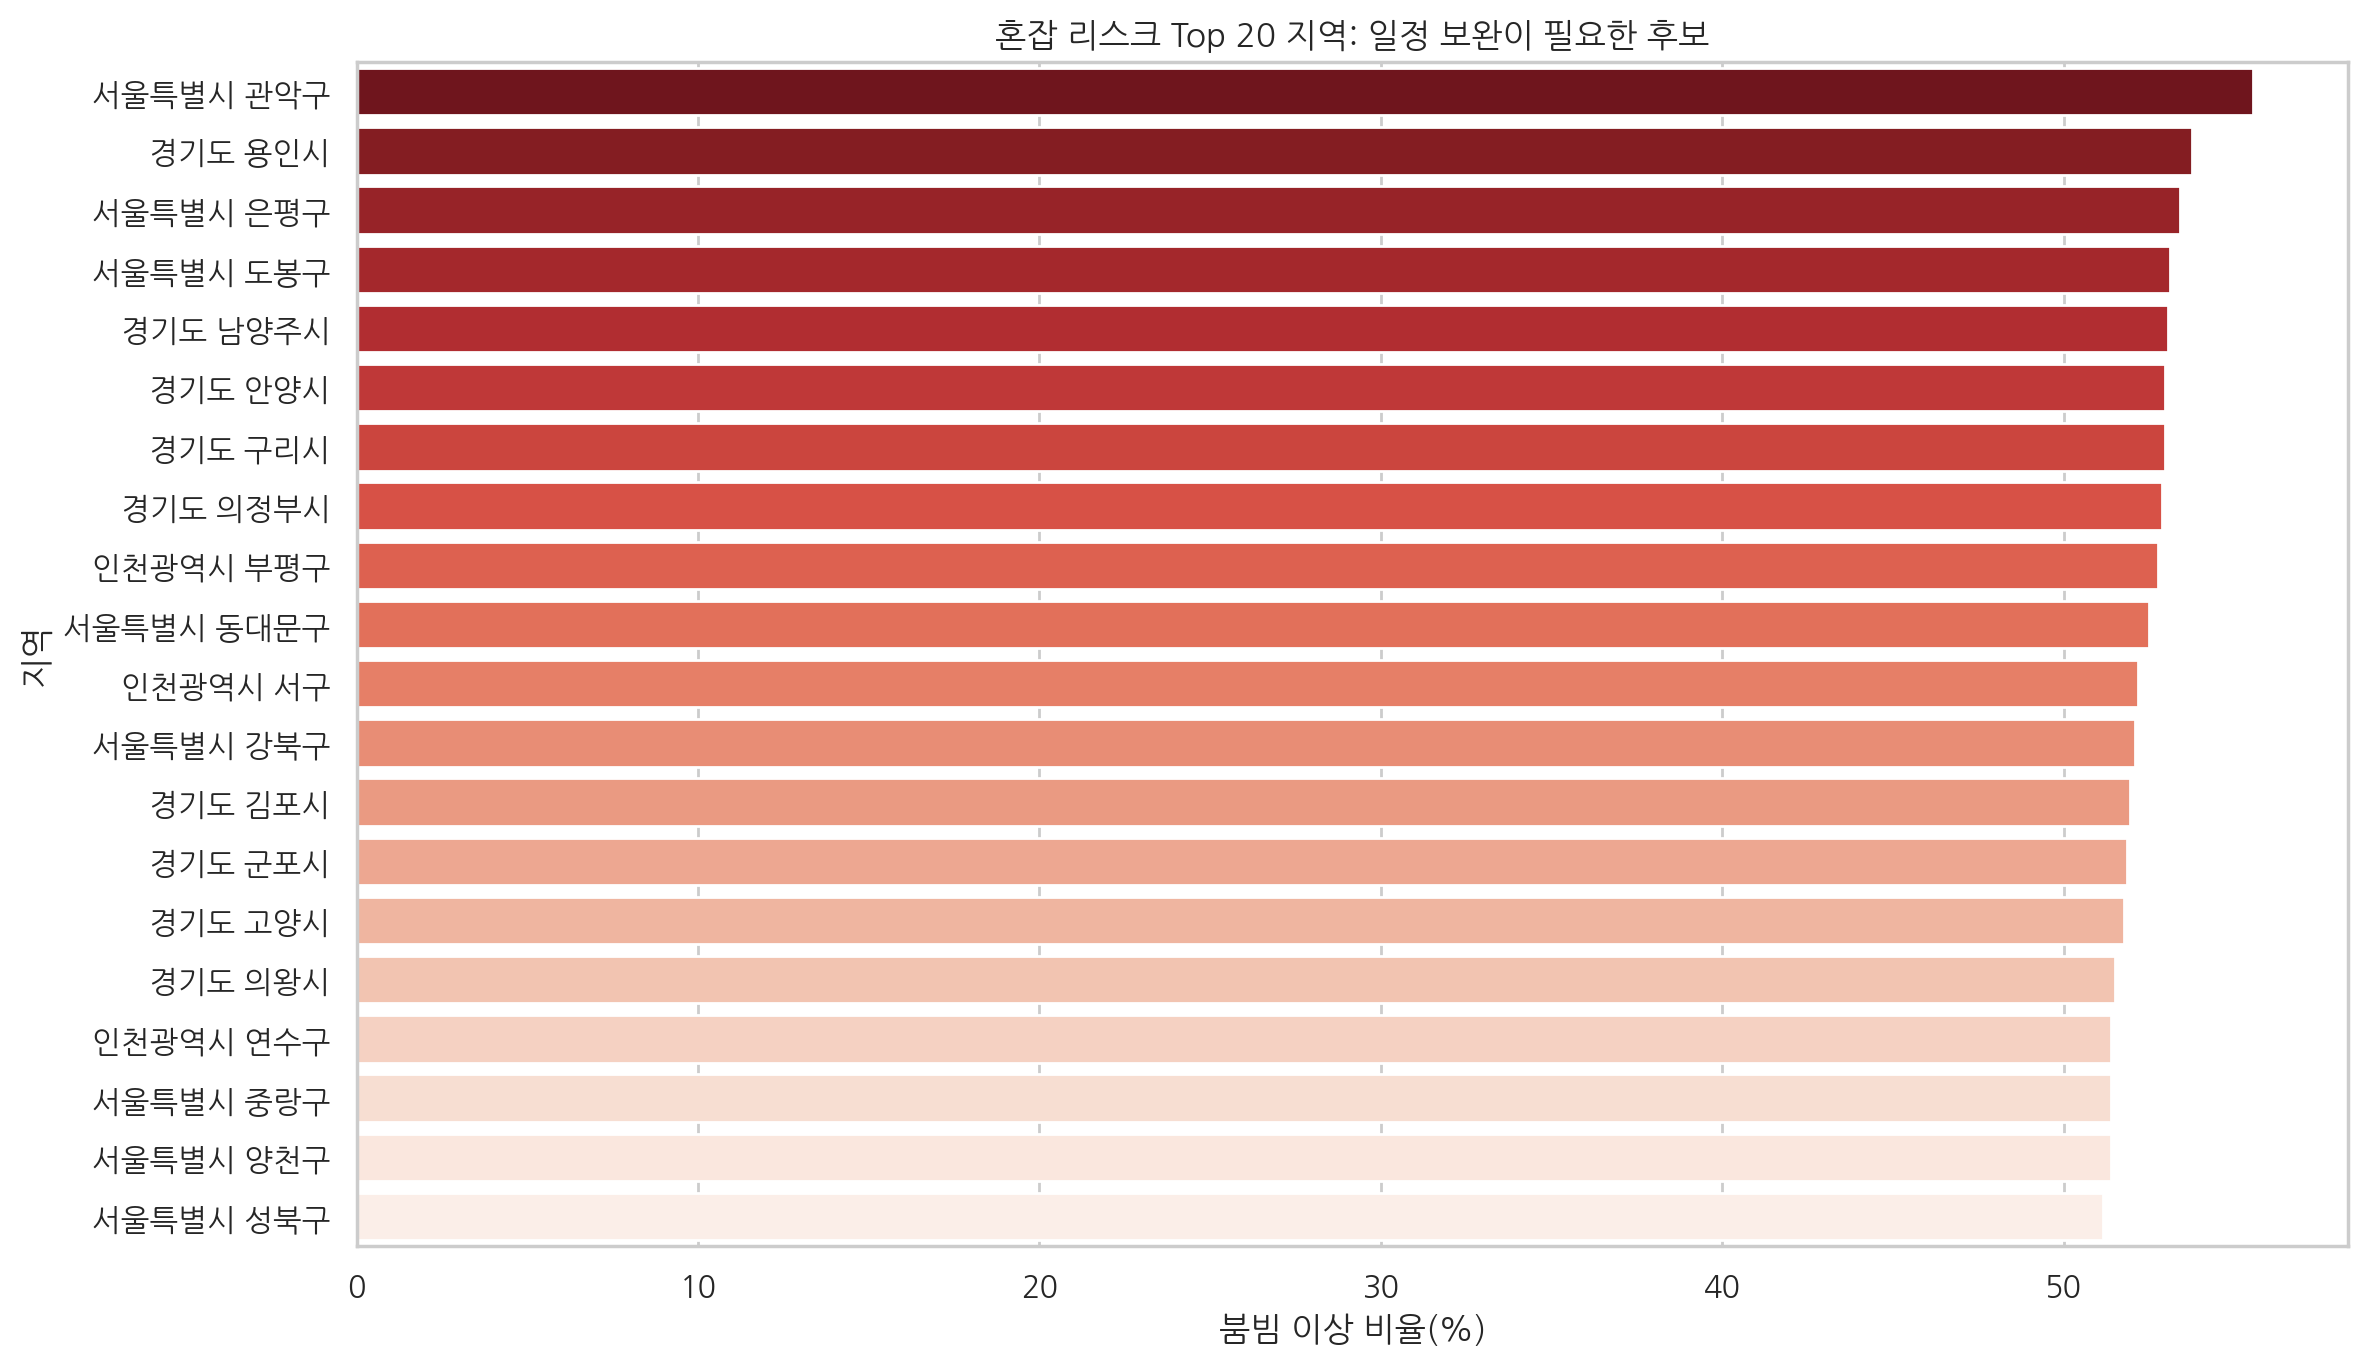

In [6]:
region_risk = cong.groupby(['시도','시군구'], observed=False).agg(
    avg_risk=('risk_score','mean'),
    busy_rate=('final_level', lambda s: (s.astype(str).isin(['붐빔','매우 붐빔'])).mean()*100)
).reset_index().sort_values('busy_rate', ascending=False).head(20)
fig, ax = plt.subplots(figsize=(12, 7))
region_risk['region'] = region_risk['시도'] + ' ' + region_risk['시군구']
sns.barplot(data=region_risk, y='region', x='busy_rate', ax=ax, palette='Reds_r')
ax.set_title('혼잡 리스크 Top 20 지역: 일정 보완이 필요한 후보')
ax.set_xlabel('붐빔 이상 비율(%)')
ax.set_ylabel('지역')
plt.tight_layout()
plt.show()


## 혼잡도 연결 문장

인기 있는 장소를 많이 추천하는 것보다, 사용자가 실제로 덜 불편하게 방문할 수 있는 시간과 지역을 제안하는 것이 서비스 가치라고 판단했다. 그래서 교통카드 기반 시간대별 혼잡도 등급을 만들고, UI 일정에 혼잡도 라벨을 붙여 추천 결과의 실행 가능성을 보완했다.

